EPANET experiments — POC (E6 mass balance, E1 flow-path mixture)

**Why.** Every dependence label so far rests on *interventional* gains (how a reading changes when one
district's demand drifts). They were validated where an exact truth exists — branch links and composite
gauges — but **loops**, where most mixed sensors live, had no ground truth. This notebook builds one from the
hydraulic solution itself, with no new simulation:

| exp. | question | truth it provides | reads |
|---|---|---|---|
| **E6** district mass balance | does every district's water add up, hour by hour? where does each district's water come from / go to? | the transit structure between districts and storage (gate for E1) | world catalogs: `flows`, `demand_series`, `pressures`, `districts` |
| **E1** flow-path destination mixture | of the water passing through a link, which share ends in each district's demand, and which in a tank? | the **exact volumetric mixture of every link**, loops included, per hour | the same |
| comparison | does the interventional mixture $v$ (and the stack's $w$) recover E1's mixture? does carrying $k$'s water mean responding to $k$'s drift? | — | `dependence_analysis/*` |

**E1 definition.** Complete mixing at nodes (EPANET's water-quality assumption). Each hour, for every node $n$
with total outflow $O_n$ (outgoing link flows + its demand + the water a filling tank keeps):
$$O_n\,\varphi_n=d_n\,e_{\text{district}(n)}+s_n\,e_{\text{storage}(n)}+\sum_{n\to v}q_{nv}\,\varphi_v ,$$
$\varphi_n$ = shares of $n$'s water by final destination. A link carries the shares of its downstream node.
Solved as a sparse linear system each hour (valid for any flow pattern). Destinations: each district's demand,
each filling tank (`storage:T`), a reservoir that receives water, and `unaccounted` — the excess inflow of a
node where the hydraulic solution does not balance it (measures solver imbalance instead of losing water).
Window mixture of link $s$: flow-weighted, $m_{s,k}=\sum_t\lvert q_s\rvert\varphi_{s,k}\big/\sum_t\lvert q_s\rvert$.

**Validated before use** (real EPANET run of D-Town, 72 h): district balance residual 2e-6 of demand; shares
sum to 1 within 2e-15; on all 141 branch links E1 equals the exact downstream demand share within 1.4e-7.
The same checks are gates here, on the study's own worlds; the branch gate's bound is the precision of the exact
reference itself (see Gates). Engine code is imported read-only. Set `STUDY` explicitly for each network.

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib, json, datetime, time
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
from fedwater.placement import mixture_probe as mp, signal_probe as sp
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 90, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = "ky72_districting_all_districts"                    # None -> the first study; set e.g. "dtown_districting_all_districts"
ATLAS = Atlas(root=EXPERIMENTS)
STUDY = STUDY or ATLAS.studies()[0]
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
BASE = REPO / "notebooks" / "outputs" / STUDY
OUT = BASE / "epanet_poc"
OUT.mkdir(parents=True, exist_ok=True)
FLOW = "flow"
GATE_BALANCE = 1e-4      # |district residual| / mean district demand (solver accuracy pinned at 1e-5)
GATE_ROWSUM = 1e-9       # destination shares of every active node sum to 1
GATE_BRANCH = None       # set in the gates cell: the study's largest branch flow-identity error (reference precision)
GATE_UNACC = 1e-4        # unaccounted share of all link volume
print(f"study {STUDY}: {len(WORLDS)} ok worlds  ->  {OUT}")

study ky72_districting_all_districts: 12 ok worlds  ->  c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\outputs\ky72_districting_all_districts\epanet_poc


 Helpers

`target_probe` / `target_windows` are copied from `dependence_compute` (same init and settled windows). The
E-functions are the ones validated above, verbatim.

In [2]:
def target_probe(w):
    sch = w.catalog.load("gt_drift_schedule")
    if sch is None or not len(sch):
        return None
    tgt = str(sch.sort_values("drift_month")["district"].iloc[0])
    dy = w.catalog.load("districts")
    return sp.Probe(districts=dy["districts"], assets=dy.get("assets") or {},
                    demand=w.catalog.load("demand_series"), pressures=pd.DataFrame(),
                    flows=w.catalog.load("flows"), schedule=sch, time=w.params["time"],
                    params={"patterns": w.params["patterns"]}, drift={"tgt_district": tgt},
                    label=w.sim_hash)


def target_windows(P, settle, patterns):
    sm, n = P.steps_month, int(P.time["n_months"])
    if float((patterns or {}).get("seasonality_scale", 0.0)) > 0:
        return mp.season_windows(P, pad=int(settle["pad"]))
    final0 = int(P.phases()["final"][0])
    try:
        s_lo, _ = mp.settled_window(P, ref_months=int(settle["ref_months"]),
                                    slack=float(settle["slack"]), pad=int(settle["pad"]),
                                    min_months=0)
        start = max(s_lo // sm, final0)
    except ValueError:
        start = final0
    need = int(settle.get("min_months", 3))
    if n - start < need:
        raise ValueError(f"unsettled: {n - start} settled month(s), {need} needed")
    return mp.baseline_window(P), (start * sm, n * sm)

In [3]:
def link_table(wn):
    rows = [(ln, wn.get_link(ln).start_node_name, wn.get_link(ln).end_node_name, type(wn.get_link(ln)).__name__)
            for ln in wn.link_name_list]
    return pd.DataFrame(rows, columns=["link", "start", "end", "link_type"]).set_index("link")


def owners(nodes, node2d, tanks, reservoirs):
    # junction -> its district; tank / reservoir -> "tank:<T>" / "reservoir:<R>"; anything else "unassigned"
    out = {}
    for n in nodes:
        if n in node2d:
            out[n] = node2d[n]
        elif n in tanks:
            out[n] = f"tank:{n}"
        elif n in reservoirs:
            out[n] = f"reservoir:{n}"
        else:
            out[n] = "unassigned"
    return out


def e6_district_balance(F, Dm, LT, districts, node2d, tanks, reservoirs):
    """Junction-set mass balance per district and hour.

    F: hours x links, L/s, .inp orientation (start -> end positive). Dm: hours x junctions, L/s.
    A link crosses district d when exactly one end is a junction of d; c(t) = its flow INTO d.
    Returns one row per (hour, district): demand, the in/out flows by partner kind, residual = net in - demand.
    """
    cols = [c for c in F.columns if c in LT.index]
    Fv = F[cols].to_numpy(float)
    own = owners(set(LT["start"]) | set(LT["end"]), node2d, tanks, reservoirs)
    os_ = np.array([own[n] for n in LT.loc[cols, "start"]])
    oe = np.array([own[n] for n in LT.loc[cols, "end"]])
    T = len(F)
    frames = []
    for d in districts:
        jd = [n for n in Dm.columns if node2d.get(n) == d]
        dem = Dm[jd].to_numpy(float).sum(axis=1)
        into = (oe == d) & (os_ != d)
        outof = (os_ == d) & (oe != d)
        acc = {k: np.zeros(T) for k in ("from_districts", "to_districts", "from_storage", "to_storage",
                                        "from_reservoir", "to_reservoir", "from_unassigned", "to_unassigned")}
        net = np.zeros(T)
        exch = {}
        for idx in np.where(into | outof)[0]:
            c = Fv[:, idx] if into[idx] else -Fv[:, idx]
            p = os_[idx] if into[idx] else oe[idx]
            kind = "districts" if p in districts else ("storage" if p.startswith("tank:") else
                                                       "reservoir" if p.startswith("reservoir:") else "unassigned")
            acc[f"from_{kind}"] += np.clip(c, 0, None)
            acc[f"to_{kind}"] += np.clip(-c, 0, None)
            exch[p] = exch.get(p, np.zeros(T)) + c
            net += c
        df = pd.DataFrame({"hour": np.arange(T), "district": d, "demand": dem, **acc, "net_in": net,
                           "residual": net - dem})
        for p, v in exch.items():
            df[f"exch:{p}"] = v
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def e6_tank_balance(F, LT, levels, tank_area, dt_s=3600.0):
    """Per tank and hour: net inflow q (L/s) vs the volume change implied by the level, A*(h[t+1]-h[t]).
    EPANET advances a tank with the flow at the start of a hydraulic step; extra intermediate steps (controls
    firing within the hour) make the hourly identity approximate, so this is a diagnostic, not an exact gate."""
    rows = []
    for t, A in tank_area.items():
        if t not in levels.columns:
            continue
        q = np.zeros(len(F))
        for ln, r in LT.iterrows():
            if ln in F.columns:
                if r["end"] == t:
                    q += F[ln].to_numpy(float)
                elif r["start"] == t:
                    q -= F[ln].to_numpy(float)
        h = levels[t].to_numpy(float)
        dv = np.r_[A * np.diff(h), np.nan]                      # m3 over the step
        exp_ = q * dt_s / 1000.0                                 # m3 from the flow at the start of the step
        rows.append(pd.DataFrame({"hour": np.arange(len(F)), "tank": t, "q_in": q, "level": h,
                                  "dV_level": dv, "dV_flow": exp_, "residual_m3": dv - exp_}))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def e1_destinations(F, Dm, LT, districts, node2d, tanks, reservoirs, hours, sd=24, eps=1e-9):
    """Flow-path destination decomposition (complete mixing at nodes, as EPANET's water quality model).

    Each hour: water leaving node n ends in a junction demand of district k, in a FILLING tank
    ("storage:<T>"), in a reservoir it flows back into ("reservoir:<R>"), or — where the hydraulic solution
    does not balance a node to solver precision — in "unaccounted" (the excess inflow of that node), so the
    accounting always closes and the solver imbalance is measured instead of silently losing water. With phi_n the destination shares of n's water and O_n its total outflow (edges + demand
    + tank sink):  O_n phi_n = demand_n e_{district(n)} + sink_n e_{storage(n)} + sum_{n->v} q phi_v.
    A link carries the shares of its downstream node. Solved as a sparse linear system (handles any flow
    pattern, not only acyclic ones). Accumulated flow-weighted over the given hours, overall and per
    hour-of-week. Returns (shares L x K, volume L, how_shares L x 7sd x K, row-sum deviation per hour).
    """
    from scipy.sparse import csr_matrix, diags
    from scipy.sparse.linalg import splu
    cols = [c for c in F.columns if c in LT.index]
    nodes = sorted(set(LT.loc[cols, "start"]) | set(LT.loc[cols, "end"]))
    ix = {n: i for i, n in enumerate(nodes)}
    dests = list(districts) + [f"storage:{t}" for t in tanks] + [f"reservoir:{r}" for r in reservoirs] + ["unaccounted"]
    di = {d: i for i, d in enumerate(dests)}
    st = LT.loc[cols, "start"].map(ix).to_numpy()
    en = LT.loc[cols, "end"].map(ix).to_numpy()
    jcols = [n for n in Dm.columns if n in ix]
    jidx = np.array([ix[n] for n in jcols])
    jdst = np.array([di.get(node2d.get(n), -1) for n in jcols])
    tix = [(ix[t], di[f"storage:{t}"]) for t in tanks if t in ix]
    rix = [(ix[r], di[f"reservoir:{r}"]) for r in reservoirs if r in ix]
    special = set(i for i, _ in tix) | set(i for i, _ in rix)
    junc_like = np.array([i not in special for i in range(len(nodes))])
    k_un = di["unaccounted"]
    N, K, L = len(nodes), len(dests), len(cols)
    Fv, Dv = F[cols].to_numpy(float), Dm[jcols].to_numpy(float)
    P = 7 * sd
    acc, vol = np.zeros((L, K)), np.zeros(L)
    acc_h, vol_h = np.zeros((L, P, K)), np.zeros((L, P))
    dev = []
    for t in hours:
        f, d = Fv[t], Dv[t]
        act = np.abs(f) > eps
        fwd = f > 0
        u = np.where(fwd, st, en)[act]
        v = np.where(fwd, en, st)[act]
        q = np.abs(f)[act]
        O = np.zeros(N)
        np.add.at(O, u, q)
        qin = np.zeros(N)
        np.add.at(qin, v, q)
        S = np.zeros((N, K))
        dn = np.zeros(N)
        dn[jidx] = d
        ok = jdst >= 0
        S[jidx[ok], jdst[ok]] += d[ok]
        O += dn
        for ti, tk in tix + rix:                                # a filling tank / receiving reservoir keeps water
            sink = max(qin[ti] - (O[ti] - dn[ti]), 0.0)
            S[ti, tk] += sink
            O[ti] += sink
        excess = np.where(junc_like, np.clip(qin - O, 0.0, None), 0.0)   # inflow a junction does not pass on
        S[:, k_un] += excess
        O += excess
        dead = O <= eps
        # a dead node (no outflow, no demand) has no outgoing edges, so its row is empty: diagonal 1, phi = 0
        A = diags(np.where(dead, 1.0, O)) - csr_matrix((q, (u, v)), shape=(N, N))
        Phi = splu(A.tocsc()).solve(S)                          # N x K
        rs = Phi.sum(axis=1)[~dead]
        dev.append(float(np.max(np.abs(rs - 1.0))) if len(rs) else 0.0)
        li = np.where(act)[0]
        contrib = q[:, None] * Phi[v]
        acc[li] += contrib
        vol[li] += q
        h = t % P
        acc_h[li, h] += contrib
        vol_h[li, h] += q
    with np.errstate(invalid="ignore", divide="ignore"):
        shares = acc / vol[:, None]
        how = acc_h / vol_h[:, :, None]
    return (pd.DataFrame(shares, index=cols, columns=dests), pd.Series(vol, index=cols),
            how, np.array(dev), dests)


def branch_downstream(wn, LT):
    # exact downstream junction sets of bridge links whose downstream side has no source (as in dependence_compute)
    G = nx.Graph()
    for ln, r in LT.iterrows():
        G.add_edge(r["start"], r["end"])
    pairs = Counter(frozenset((r["start"], r["end"])) for _, r in LT.iterrows())
    sources = set(wn.tank_name_list) | set(wn.reservoir_name_list)
    out = {}
    for u, v in nx.bridges(G):
        e = frozenset((u, v))
        if pairs[e] > 1:
            continue
        G.remove_edge(u, v)
        cu = nx.node_connected_component(G, u)
        G.add_edge(u, v)
        cv = set(G.nodes) - cu
        su, sv = bool(cu & sources), bool(cv & sources)
        if su != sv:
            dn = cv if su else cu
            for ln, r in LT.iterrows():
                if frozenset((r["start"], r["end"])) == e:
                    out[ln] = dn
    return out

 The pass — every world

Per world: E6 on **every hour** of the simulation; the tank diagnostic; E1 on the **init** and **settled**
windows (every hour of each). Per-link mixtures are kept per window and per hour-of-week. Failures are reported
in a table, never skipped silently.

In [4]:
E6_ROWS, TANK_ROWS, E1_ROWS, E1_HOW, GATE_ROWS, issues = [], [], [], [], [], []
NET_DONE = {}
for wi, r in WORLDS.iterrows():
    h = r["sim_hash"]
    try:
        t0 = time.time()
        w = ATLAS.world(h)
        P = target_probe(w)
        if P is None:
            raise ValueError("no drift schedule")
        WI, WF = target_windows(P, w.params["sensor_placement"]["probe"]["settle"], w.params["patterns"])
        sd = P.steps_day
        wn = w.network_model
        dy = w.catalog.load("districts")
        districts = list(dy["districts"])
        node2d = {str(n): d for d, ns in dy["districts"].items() for n in ns}
        F = w.catalog.load("flows")
        F.columns = [str(c) for c in F.columns]
        D_ = w.catalog.load("demand_series")
        Dm = D_[[c for c in D_.columns if str(c) in set(wn.junction_name_list)]].copy()
        Dm.columns = [str(c) for c in Dm.columns]
        n = min(len(F), len(Dm))
        F, Dm = F.iloc[:n].reset_index(drop=True), Dm.iloc[:n].reset_index(drop=True)
        pres = w.catalog.load("pressures")
        tanks, reservoirs = list(wn.tank_name_list), list(wn.reservoir_name_list)
        levels = pres[[t for t in tanks if t in pres.columns]].iloc[:n].reset_index(drop=True)
        LT = link_table(wn)
        meta = {"network": r["network"], "districting": r["districting"], "world": h[:8], "drift": P.drift["tgt_district"]}

        # E6
        e6 = e6_district_balance(F, Dm, LT, districts, node2d, tanks, reservoirs)
        e6["window"] = np.select([e6["hour"].between(WI[0], WI[1] - 1), e6["hour"].between(WF[0], WF[1] - 1)],
                                 ["init", "settled"], "other")
        E6_ROWS.append(e6.assign(**meta))
        area = {t: np.pi * wn.get_node(t).diameter ** 2 / 4 for t in tanks if wn.get_node(t).vol_curve_name is None}
        tb = e6_tank_balance(F, LT, levels, area, dt_s=86400.0 / sd)
        if len(tb):
            TANK_ROWS.append(tb.assign(**meta))
        mean_dem = e6.groupby("district")["demand"].transform("mean")
        bal = float((e6["residual"].abs() / mean_dem).max())

        # E1 on both windows
        rs_dev, unacc = [], []
        for win, (lo, hi) in (("init", WI), ("settled", WF)):
            sh, vol, how, dev, dests = e1_destinations(F, Dm, LT, districts, node2d, tanks, reservoirs,
                                                       range(lo, hi), sd=sd)
            rs_dev.append(float(dev.max()) if len(dev) else np.nan)
            unacc.append(float((sh["unaccounted"].fillna(0) * vol).sum() / max(vol.sum(), 1e-12)))
            E1_ROWS.append(sh.assign(volume=vol, mean_abs_flow=vol / (hi - lo), window=win, link=sh.index)
                           .reset_index(drop=True).assign(**meta))
            how32 = np.asarray(how, np.float32)
            for k_, dname in enumerate(dests):
                df = pd.DataFrame(how32[:, :, k_], columns=[f"h{t:03d}" for t in range(how32.shape[1])])
                df.insert(0, "dest", dname)
                df.insert(0, "window", win)
                df.insert(0, "link", list(sh.index))
                E1_HOW.append(df.assign(**meta))
        GATE_ROWS.append({**meta, "hours": n, "E6 max |residual|/mean demand": bal,
                          "E1 max row-sum deviation": max(rs_dev), "E1 unaccounted share (max of windows)": max(unacc),
                          "seconds": round(time.time() - t0, 1)})
        if r["network"] not in NET_DONE:
            NET_DONE[r["network"]] = LT
        print(f"\r  {wi + 1}/{len(WORLDS)} — {meta['districting']} {meta['drift']} ({time.time() - t0:.0f}s)          ",
              end="", flush=True)
        del F, Dm, pres, D_
    except Exception as exc:
        issues.append({"world": h[:8], "districting": r["districting"], "issue": f"{type(exc).__name__}: {exc}"[:240]})
print()
if issues:
    display(Markdown("**Worlds not analysed**")); display(pd.DataFrame(issues))
if not GATE_ROWS:
    raise RuntimeError("no world was analysed — see the table above")
E6 = pd.concat(E6_ROWS, ignore_index=True)
TANK = pd.concat(TANK_ROWS, ignore_index=True) if TANK_ROWS else pd.DataFrame()
E1 = pd.concat(E1_ROWS, ignore_index=True)
E1H = pd.concat(E1_HOW, ignore_index=True)
GATES = pd.DataFrame(GATE_ROWS)
E6.to_parquet(OUT / "e6_district_hourly.parquet", index=False)
if len(TANK):
    TANK.to_parquet(OUT / "e6_tank_hourly.parquet", index=False)
E1.to_parquet(OUT / "e1_link_window.parquet", index=False)
E1H.to_parquet(OUT / "e1_link_hour_of_week.parquet", index=False)

  12/12 — spectral District_D (31s)              


 Gates

| gate | rule | why |
|---|---|---|
| G-E6 | max over hours and districts of $\lvert\text{net inflow}-\text{demand}\rvert/\overline{\text{demand}}<10^{-4}$ | EPANET balances every junction; a district residual means the accounting (or the solve) is wrong |
| G-E1a | destination shares of every active node sum to 1 (deviation $<10^{-9}$) | the linear system is solved and closed |
| G-E1b | `unaccounted` share of all link volume $<10^{-4}$ | solver imbalance is negligible; links above 1 % are listed (expected: near-zero-flow links) |
| G-E1c | on branch links, $\lvert$E1 share − exact downstream demand share$\rvert$ (`dependence/branch`) ≤ the reference's own precision: the study's largest branch flow-identity error (`series_err_max`, branch flow vs $\sum$ downstream demand) | E1 reproduces the only exact mixture we had before. E1 is computed from the simulated **flows**, the reference from the **demand series**; the two agree only to solver precision (accuracy 1e-5), so E1 cannot be held to a tighter bound than that identity. The worst branches are listed with their own identity error |

In [5]:
br_path = BASE / "dependence" / "branch.parquet"
g_br = np.nan
if br_path.exists():
    BRx = pd.read_parquet(br_path)
    dcols = sorted(c[len("w_exact_init_"):] for c in BRx.columns if c.startswith("w_exact_init_"))
    e1i = E1[E1["window"] == "init"].set_index(["world", "link"])
    brows = []
    for rr in BRx.itertuples():
        key = (rr.world, str(rr.element))
        if key not in e1i.index or not e1i.at[key, "volume"] > 0:
            continue
        brows.append({"districting": rr.districting, "world": rr.world, "link": str(rr.element),
                      "err": max(abs(float(e1i.at[key, d]) - float(getattr(rr, f"w_exact_init_{d}") or 0.0))
                                 for d in dcols if d in e1i.columns),
                      "series_err_max": float(rr.series_err_max), "n_down": rr.n_down,
                      "mean_abs_flow": float(e1i.at[key, "mean_abs_flow"]),
                      "unaccounted": float(e1i.at[key, "unaccounted"])})
    BCHK = pd.DataFrame(brows)
    BCHK.to_parquet(OUT / "e1_branch_check.parquet", index=False)
    g_br = float(BCHK["err"].max()) if len(BCHK) else np.nan
    GATE_BRANCH = float(BRx["series_err_max"].max())          # the reference's own precision in this study
    GATES["E1 branch max |E1 - exact| (study)"] = g_br
G_ = [{"gate": "G-E6 district balance", "value": f"{GATES['E6 max |residual|/mean demand'].max():.1e}",
       "passed": bool(GATES["E6 max |residual|/mean demand"].max() < GATE_BALANCE)},
      {"gate": "G-E1a shares sum to 1", "value": f"{GATES['E1 max row-sum deviation'].max():.1e}",
       "passed": bool(GATES["E1 max row-sum deviation"].max() < GATE_ROWSUM)},
      {"gate": "G-E1b unaccounted volume", "value": f"{GATES['E1 unaccounted share (max of windows)'].max():.1e}",
       "passed": bool(GATES["E1 unaccounted share (max of windows)"].max() < GATE_UNACC)},
      {"gate": "G-E1c branches = exact (≤ reference precision)",
       "value": (f"{g_br:.1e} (bound {GATE_BRANCH:.1e})" if np.isfinite(g_br) else "n/a (no dependence/branch)"),
       "passed": bool(np.isfinite(g_br) and g_br <= GATE_BRANCH)}]
GT = pd.DataFrame(G_)
display(GT)
display(Markdown("per world"))
display(GATES)
POC_OK = bool(GT["passed"].all())
if br_path.exists() and len(BCHK):
    display(Markdown("**G-E1c detail** — worst branches: E1 error next to that branch's own flow-identity error "
                     "(`series_err_max`). An E1 error at or below the identity error is solver precision, not an E1 defect."))
    display(BCHK.sort_values("err", ascending=False).drop_duplicates(["districting", "link"]).head(10)
            .assign(**{"err / series_err_max": lambda d: d["err"] / d["series_err_max"]}).round(8))
display(Markdown("**All gates pass.**" if POC_OK else "**A gate failed — the comparisons below are not to be read.**"))
una = E1[(E1["unaccounted"] > 0.01) & (E1["volume"] > 0)][["districting", "world", "window", "link", "unaccounted", "mean_abs_flow"]]
display(Markdown(f"links with > 1 % unaccounted water: {len(una)} (expected: near-zero-flow links)"))
display(una.sort_values("unaccounted", ascending=False).head(20))

,gate,value,passed
0,G-E6 district balance,9.2e-06,True
1,G-E1a shares sum to 1,2.3e-15,True
2,G-E1b unaccounted volume,3.4e-06,True
3,G-E1c branches = exact (≤ reference precision),2.3e-05 (bound 2.0e-04),True


per world

,network,districting,world,drift,hours,E6 max |residual|/mean demand,E1 max row-sum deviation,E1 unaccounted share (max of windows),seconds,E1 branch max |E1 - exact| (study)
0,ky72,fast_greedy,0b4750d3,District_A,33768,0.000009,1.998401e-15,0.000003,27.4,0.000023
1,ky72,fast_greedy,13f0f426,District_B,33768,0.000005,1.998401e-15,0.000003,26.2,0.000023
2,ky72,fast_greedy,312ef90c,District_C,33768,0.000009,2.109424e-15,0.000003,28.6,0.000023
3,ky72,fast_greedy,8a9b36d7,District_D,33768,0.000009,1.998401e-15,0.000003,36.0,0.000023
4,ky72,girvan_newman,35d8d9bc,District_A,35280,0.000005,1.665335e-15,0.000003,18.5,0.000023
5,ky72,girvan_newman,420262ff,District_B,35280,0.000003,1.887379e-15,0.000003,29.3,0.000023
6,ky72,girvan_newman,13e16814,District_C,35280,0.000008,1.776357e-15,0.000003,21.8,0.000023
7,ky72,girvan_newman,f90a7f06,District_D,35280,0.000006,2.220446e-15,0.000003,35.4,0.000023
8,ky72,spectral,27ccb25e,District_A,33264,0.000006,1.665335e-15,0.000003,17.5,0.000023
9,ky72,spectral,dabef050,District_B,33264,0.000005,1.665335e-15,0.000003,17.1,0.000023


**G-E1c detail** — worst branches: E1 error next to that branch's own flow-identity error (`series_err_max`). An E1 error at or below the identity error is solver precision, not an E1 defect.

,districting,world,link,err,series_err_max,n_down,mean_abs_flow,unaccounted,err / series_err_max
342,fast_greedy,312ef90c,P-136,0.000023,0.000101,1,0.005515,0.000023,0.223699
1002,girvan_newman,13e16814,P-136,0.000021,0.000086,1,0.006165,0.000021,0.240792
1332,spectral,27ccb25e,P-136,0.000021,0.000065,1,0.006186,0.000021,0.316262
14,fast_greedy,0b4750d3,P-140,0.000019,0.000049,1,0.006530,0.000019,0.390650
349,fast_greedy,312ef90c,P-158,0.000019,0.000080,1,0.006353,0.000019,0.236178
1009,girvan_newman,13e16814,P-158,0.000018,0.000072,1,0.007101,0.000018,0.245803
1339,spectral,27ccb25e,P-158,0.000018,0.000071,1,0.007126,0.000018,0.248663
1664,spectral,44043280,P-140,0.000017,0.000071,1,0.007325,0.000017,0.245459
674,girvan_newman,35d8d9bc,P-140,0.000017,0.000049,1,0.007299,0.000017,0.343282
450,fast_greedy,312ef90c,P-57,0.000016,0.000068,1,0.007983,0.000016,0.232469


**All gates pass.**

links with > 1 % unaccounted water: 0 (expected: near-zero-flow links)

,districting,world,window,link,unaccounted,mean_abs_flow


 E6 · Where each district's water comes from and goes to

Window means (L/s) per district: its demand; inflow from / outflow to other districts, tanks and reservoirs;
`through` = inflow from other districts / own demand (> 1: the district is a conduit for others' water).
The **exchange matrix** (init window — identical across the worlds of a partition) gives the mean net flow into
each district (rows) from each partner (columns). The **change** panels show, in the world where $k$ drifts,
settled − init: how $k$'s drift reroutes water between districts and storage.

**Init window** (one world per partition)

demand  from_districts  to_districts  from_storage  to_storage  from_reservoir  to_reservoir  through
districting   district                                                                                                         
fast_greedy   District_A   7.047          19.279        45.386         0.000       0.000          33.154           0.0    2.736
              District_B   7.022          10.372         3.209         0.040       0.182           0.000           0.0    1.477
              District_C  10.718          21.739        11.512        16.807      16.316           0.000           0.0    2.028
              District_D   8.717          13.412         4.695         0.000       0.000           0.000           0.0    1.539
girvan_newman District_A  14.697          32.597        18.690        16.422      15.632           0.000           0.0    2.218
              District_B   5.434           7.766         2.222         0.000       0.110           0.000           0.0    1.429
              District_C   7.821           9.065        34.067         0.000       0.000          32.823           0.0    1.159
              District_D   5.551           8.621         3.070         0.000       0.000           0.000           0.0    1.553
spectral      District_A  11.777         107.438        96.196        16.097      15.563           0.000           0.0    9.123
              District_B   9.925          85.798        75.723         0.010       0.159           0.000           0.0    8.644
              District_C   2.931           1.528        31.715         0.000       0.000          33.119           0.0    0.521
              District_D   8.870           8.870         0.000         0.000       0.000           0.000           0.0    1.000

consistency with `districting_table` (Σ|mean boundary flow| / demand vs E6's (in + out) / demand — equal only if no boundary link reverses within the window)

E6 (in+out)/demand  boundary_flow_over_demand
districting   district                                                 
fast_greedy   District_A               9.177                      4.760
              District_B               1.934                      1.379
              District_C               3.102                      0.968
              District_D               2.077                      1.564
girvan_newman District_A               3.490                      2.401
              District_B               1.838                      1.342
              District_C               5.515                      4.511
              District_D               2.106                      1.000
spectral      District_A              17.291                     11.084
              District_B              16.274                      9.216
              District_C              11.342                     10.299
              District_D               1.000                      1.000

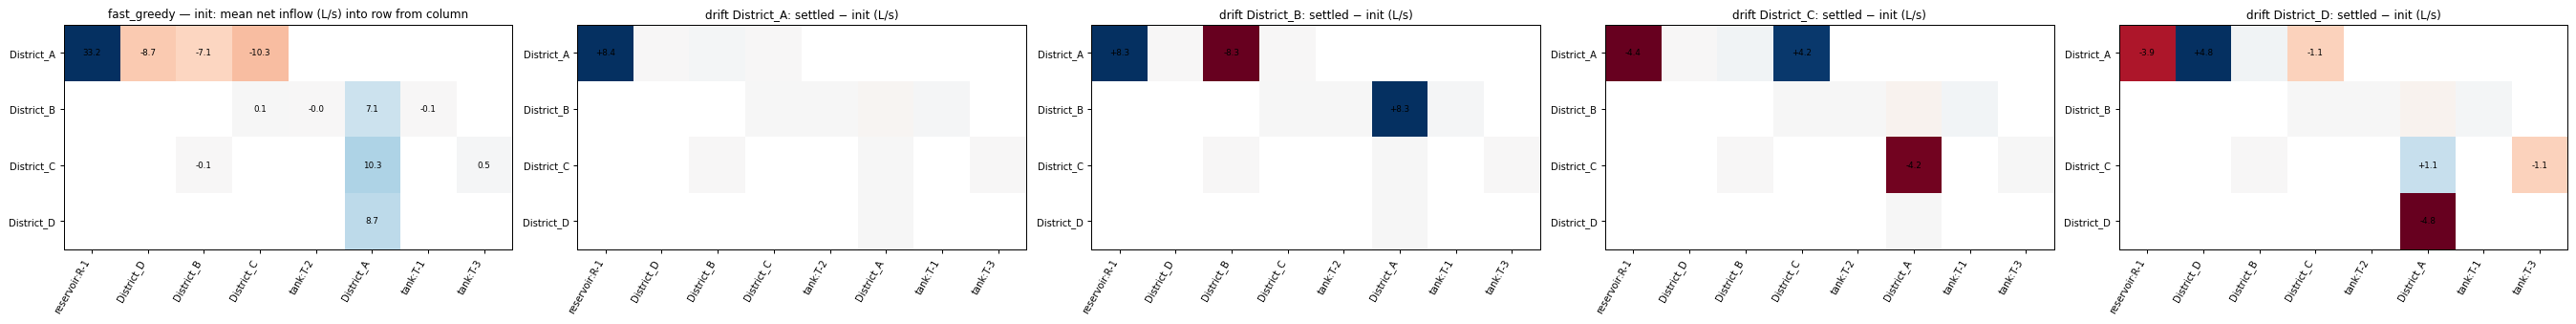

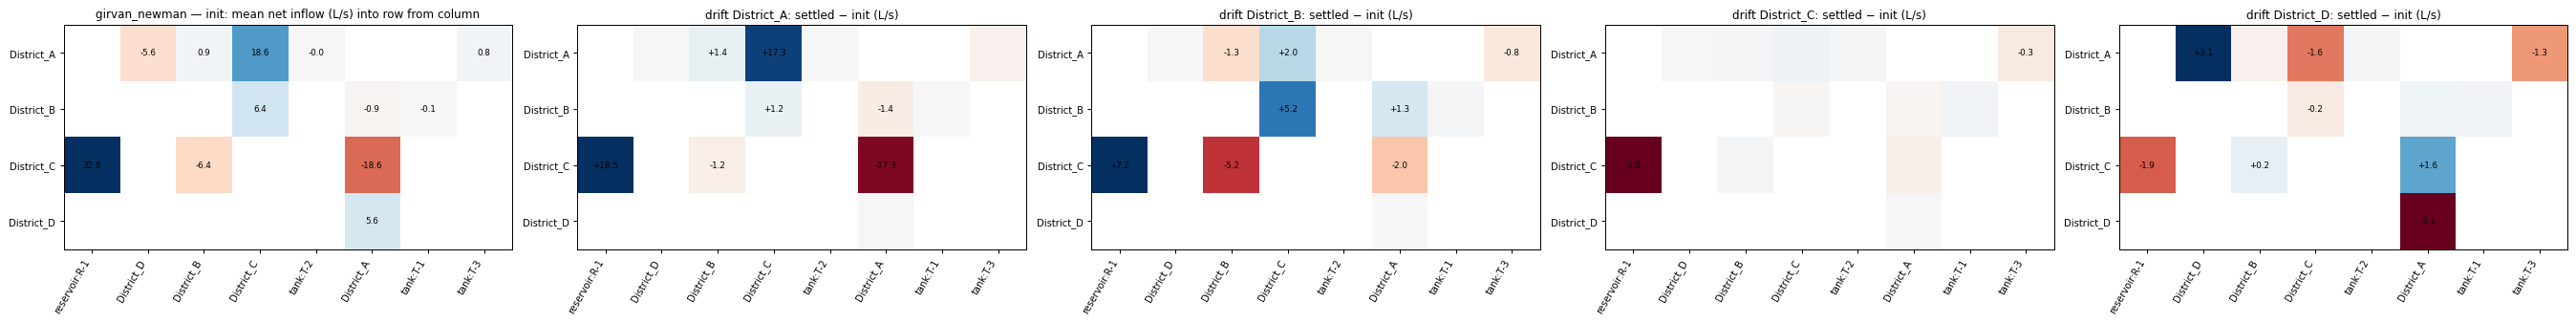

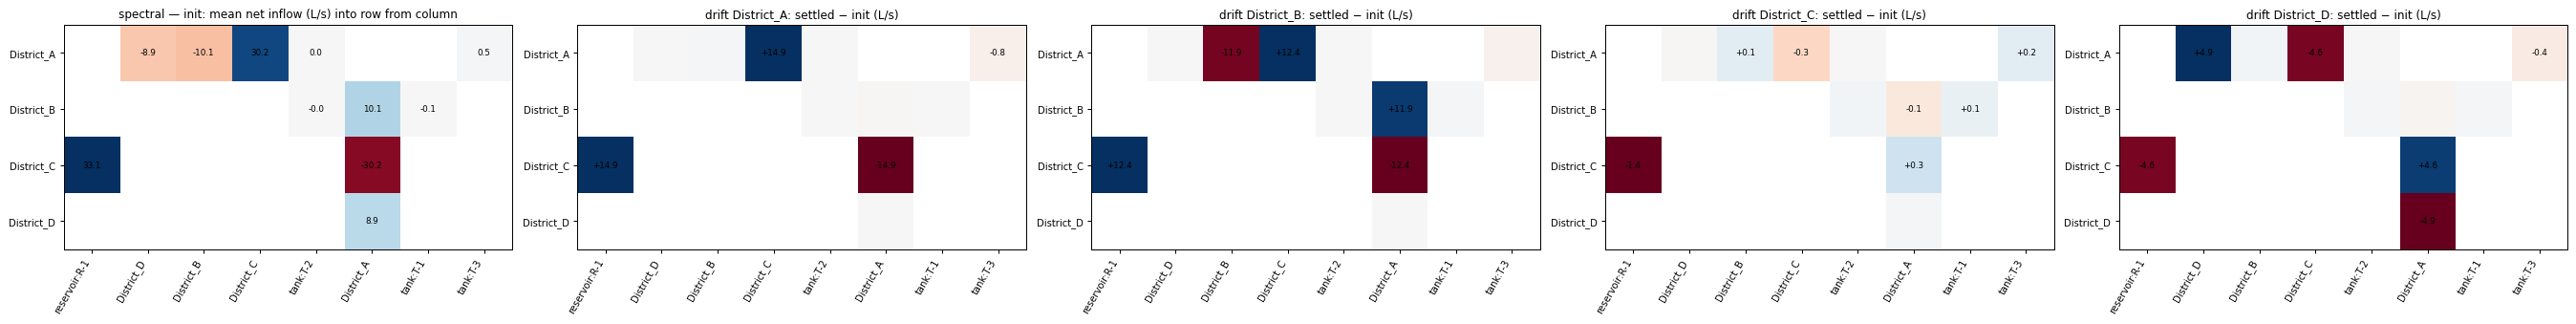

**Tank diagnostic** — hourly $\lvert A\,\Delta h-q\,\Delta t\rvert$ / mean $\lvert q\,\Delta t\rvert$ (quantiles). Not a gate: EPANET inserts intermediate steps when a control fires within the hour, so the hourly identity holds only between such events.

0.50  0.90   0.99
districting   tank                   
fast_greedy   T-1    0.0   0.0  0.000
              T-2    0.0   0.0  0.000
              T-3    0.0   0.0  1.735
girvan_newman T-1    0.0   0.0  0.000
              T-2    0.0   0.0  0.000
              T-3    0.0   0.0  1.702
spectral      T-1    0.0   0.0  0.000
              T-2    0.0   0.0  0.000
              T-3    0.0   0.0  1.761

In [6]:
def assert_ok():
    if not POC_OK:
        raise RuntimeError("a gate failed — comparisons not computed")


assert_ok()
cols_ = ["demand", "from_districts", "to_districts", "from_storage", "to_storage", "from_reservoir", "to_reservoir"]
win = E6[E6["window"] != "other"].groupby(["districting", "drift", "district", "window"])[cols_].mean()
win["through"] = win["from_districts"] / win["demand"]
first = WORLDS.groupby("districting")["sim_hash"].first().str[:8]
display(Markdown("**Init window** (one world per partition)"))
display(win.xs("init", level="window").reset_index().merge(first.rename("world").reset_index(), on="districting")
        .drop_duplicates(["districting", "district"]).drop(columns=["drift", "world"]).set_index(["districting", "district"]).round(3))
dt_path = BASE / "dependence_analysis" / "districting_table.parquet"
if dt_path.exists():
    DTb = pd.read_parquet(dt_path).set_index(["districting", "district"])["boundary_flow_over_demand"]
    chk_ = win.xs("init", level="window").groupby(["districting", "district"])[["from_districts", "to_districts", "demand"]].first()
    chk_["E6 (in+out)/demand"] = (chk_["from_districts"] + chk_["to_districts"]) / chk_["demand"]
    chk_ = chk_.join(DTb)
    display(Markdown("consistency with `districting_table` (Σ|mean boundary flow| / demand vs E6's (in + out) / demand — "
                     "equal only if no boundary link reverses within the window)"))
    display(chk_[["E6 (in+out)/demand", "boundary_flow_over_demand"]].round(3))
E6.attrs = {}
exch_cols = [c for c in E6.columns if c.startswith("exch:")]
EX = (E6[E6["window"] != "other"].groupby(["districting", "drift", "district", "window"])[exch_cols].mean())
EX.reset_index().to_parquet(OUT / "e6_exchange_window.parquet", index=False)
for m in sorted(E6["districting"].unique()):
    ws = WORLDS[WORLDS["districting"] == m]
    names = sorted(E6[E6["districting"] == m]["district"].unique())
    ex0 = EX.xs((m, "init"), level=("districting", "window")).groupby("district").first()
    ex0 = ex0.loc[:, ex0.notna().any()].reindex(names)
    ex0.columns = [c[5:] for c in ex0.columns]
    fig, axes = plt.subplots(1, 1 + len(names), figsize=(6 * (1 + len(names)), 30), squeeze=False)
    ax = axes[0, 0]
    vmax = np.nanmax(np.abs(ex0.to_numpy(float)))
    im = ax.imshow(ex0.to_numpy(float), cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(ex0.shape[1]), ex0.columns, rotation=60, ha="right"); ax.set_yticks(range(len(names)), names)
    for i in range(ex0.shape[0]):
        for j in range(ex0.shape[1]):
            v = ex0.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"{m} — init: mean net inflow (L/s) into row from column")
    for c_, k in enumerate(names, start=1):
        ax = axes[0, c_]
        try:
            a = EX.xs((m, k, "settled"), level=("districting", "drift", "window"))
            b = EX.xs((m, k, "init"), level=("districting", "drift", "window"))
        except KeyError:
            ax.axis("off"); continue
        dlt = (a - b).reindex(names)
        dlt = dlt.loc[:, [f"exch:{c}" for c in ex0.columns if f"exch:{c}" in dlt.columns]]
        vm = np.nanmax(np.abs(dlt.to_numpy(float))) or 1.0
        ax.imshow(dlt.to_numpy(float), cmap="RdBu", vmin=-vm, vmax=vm)
        ax.set_xticks(range(dlt.shape[1]), [c[5:] for c in dlt.columns], rotation=60, ha="right")
        ax.set_yticks(range(len(names)), names)
        for i in range(dlt.shape[0]):
            for j in range(dlt.shape[1]):
                v = dlt.iat[i, j]
                if np.isfinite(v) and abs(v) > 0.05 * vm:
                    ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=7)
        ax.set_title(f"drift {k}: settled − init (L/s)")
    fig.tight_layout(); plt.show()
if len(TANK):
    TANK["rel"] = TANK["residual_m3"].abs() / TANK.groupby(["world", "tank"])["dV_flow"].transform(lambda x: x.abs().mean())
    display(Markdown("**Tank diagnostic** — hourly $\\lvert A\\,\\Delta h-q\\,\\Delta t\\rvert$ / mean $\\lvert q\\,\\Delta t\\rvert$ (quantiles). "
                     "Not a gate: EPANET inserts intermediate steps when a control fires within the hour, so the hourly "
                     "identity holds only between such events."))
    display(TANK.groupby(["districting", "tank"])["rel"].quantile([0.5, 0.9, 0.99]).unstack().round(3))

 E1 · The exact mixture of every link, against the labels

Per link and window: $m_{s,k}$ (share of its water ending in district $k$'s demand) and the **storage share**
$m_{s,\text{sto}}$ (ending in a filling tank). The demand mixture used for comparison is renormalised over the
districts. Compared with:

| label | origin | expected relation to E1 |
|---|---|---|
| $v_{s,k}$ | interventional: significant positive demand gains × district volume (`sensor_demand_mixture`) | equals the **marginal** routing of $k$'s demand through $s$; equals $m$ only when routing is proportional (exact on branches) |
| $w_{s,k}$ | the label stack (shape, magnitude rule) | none by construction (§2a of the analysis showed it is not a volume share) |

Three tests: **(a)** storage share vs the v2 storage class and the native storage share of the response;
**(b)** $L_1$ distance $\tfrac12\lVert\cdot\rVert_1$ of $v$ and $w$ to $m$, by topology and class; **(c)** does
carrying $k$'s water predict responding to $k$'s drift (AUC), and **(d)** is the interventional demand gain the
change in $k$-bound water? With $V_{s,k}=m_{s,k}\,\overline{\lvert q_s\rvert}$ (L/s of $k$'s water through $s$) in the
world where $k$ drifts, $\hat g_{s,k}=\Delta V_{s,k}/\Delta\bar D_k$ (settled − init) is E1's own gain, to set
against the oriented interventional $g^{\text{dem}}_{s,k}$ (weekly-profile projection — so the comparison is
approximate; $g^{\text{dem}}$ also carries tank-level effects).

**(a) storage share of each link's water vs the storage labels**

,districting,AUC storage share -> v2 storage class,Spearman storage share vs native storage share of response,median storage share: storage-class,median storage share: demand-class,branch links with storage share > 0
0,fast_greedy,0.960,0.708,0.451,0.0,0
1,girvan_newman,0.956,0.750,0.441,0.0,0
2,spectral,0.969,0.710,0.429,0.0,0


**(b) $\tfrac12\lVert v-m\rVert_1$ and $\tfrac12\lVert w-m\rVert_1$** (median, q90) and how often $v$ is defined

links  v_defined  L1_v_med  L1_v_q90  L1_w_med  L1_w_q90
districting   topo          class                                                            
fast_greedy   branch        demand     165      1.000     0.000     0.000     0.000     0.017
              loop          demand     103      0.942     0.022     0.247     0.100     0.294
                            storage    318      0.484     0.178     0.764     0.342     0.628
              source_bridge demand       4      0.000       NaN       NaN     0.300     0.637
                            storage     12      0.333     0.029     0.029     0.255     0.258
girvan_newman branch        demand     165      1.000     0.000     0.000     0.000     0.013
              loop          demand     119      0.950     0.042     0.237     0.073     0.363
                            storage    302      0.434     0.318     0.576     0.468     0.705
              source_bridge demand       4      0.000       NaN       NaN     0.297     0.636
                            storage     12      0.333     0.021     0.021     0.307     0.482
spectral      branch        demand     165      1.000     0.000     0.000     0.000     0.015
              loop          demand     110      0.945     0.041     0.204     0.067     0.290
                            storage    311      0.341     0.208     0.435     0.219     0.484
              source_bridge demand       4      0.000       NaN       NaN     0.301     0.881
                            storage     12      0.333     0.023     0.023     0.153     0.429

dominant district: $v$ vs E1 (links with $v$ defined)

districting    class  
fast_greedy    demand     0.992
               storage    0.854
girvan_newman  demand     0.982
               storage    0.859
spectral       demand     1.000
               storage    0.964
Name: agree, dtype: float64

how pure is each link's water by E1? (share of its own home district's demand)

10%    50%    90%
districting   class                       
fast_greedy   demand   0.941  1.000  1.000
              storage  0.205  0.436  0.923
girvan_newman demand   0.822  1.000  1.000
              storage  0.244  0.488  0.781
spectral      demand   0.890  1.000  1.000
              storage  0.202  0.495  0.880

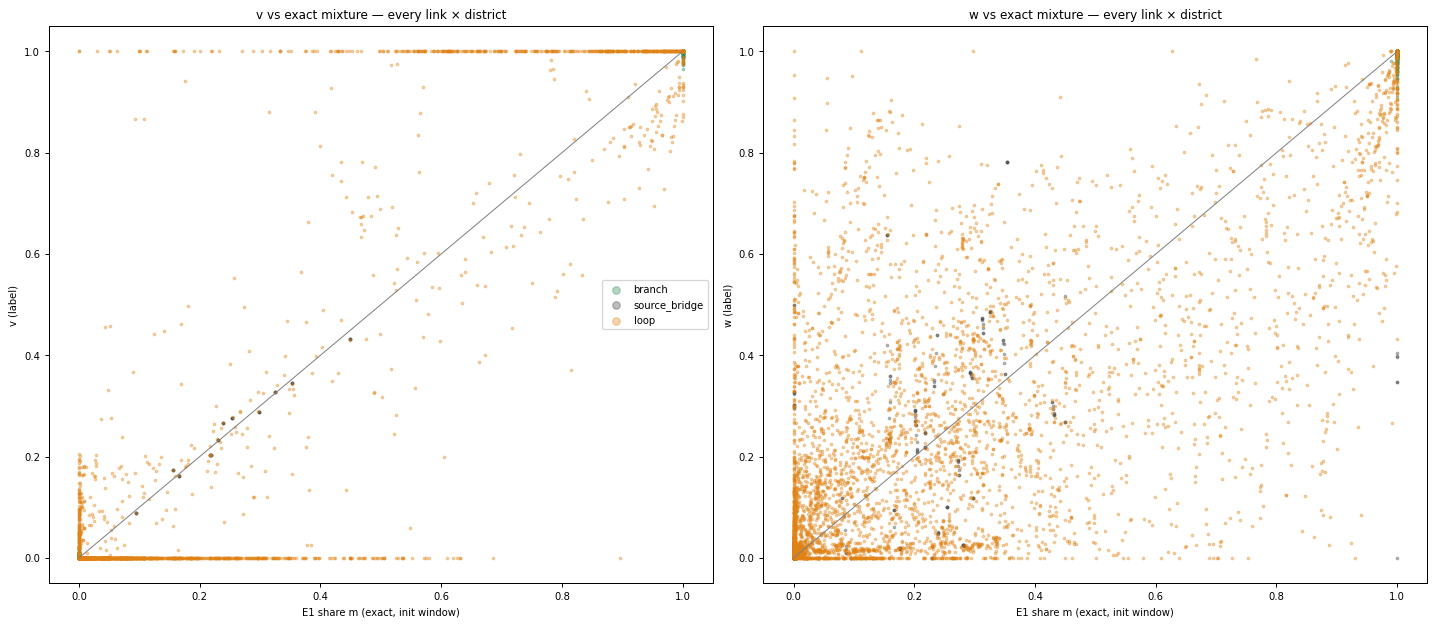

**(c) does carrying $k$'s water (E1) predict a significant response to $k$'s drift?** (off-diagonal)

AUC of m_{s,k}                      P(responds | m < 0.01)                      P(responds | m >= 0.05)                     
responds via             dem  shape    sto    tot                    dem  shape    sto    tot                     dem  shape    sto    tot
districting                                                                                                                               
fast_greedy            0.697  0.827  0.931  0.893                  0.238  0.314  0.253  0.193                   0.489  0.809  0.949  0.885
girvan_newman          0.772  0.700  0.920  0.837                  0.192  0.227  0.198  0.194                   0.614  0.502  0.913  0.724
spectral               0.633  0.883  0.932  0.861                  0.282  0.170  0.290  0.126                   0.443  0.807  0.967  0.779

**(d) interventional demand gain vs E1's gain** (link-worlds with a significant demand response)

,districting,topo,own,n (sig_dem),Spearman g_e1 vs g_dem,median g_dem / g_e1,sign agree
0,fast_greedy,branch,False,25,NaN,NaN,0.000
1,fast_greedy,branch,True,165,1.000,0.995,1.000
2,fast_greedy,loop,False,604,-0.387,-2.861,0.237
3,fast_greedy,loop,True,392,0.375,0.350,0.559
4,fast_greedy,source_bridge,False,12,0.846,8.062,1.000
5,fast_greedy,source_bridge,True,4,-1.000,2.199,1.000
6,girvan_newman,branch,False,24,NaN,NaN,0.000
7,girvan_newman,branch,True,165,1.000,0.998,1.000
8,girvan_newman,loop,False,612,-0.414,-2.372,0.217
9,girvan_newman,loop,True,365,0.379,0.369,0.581


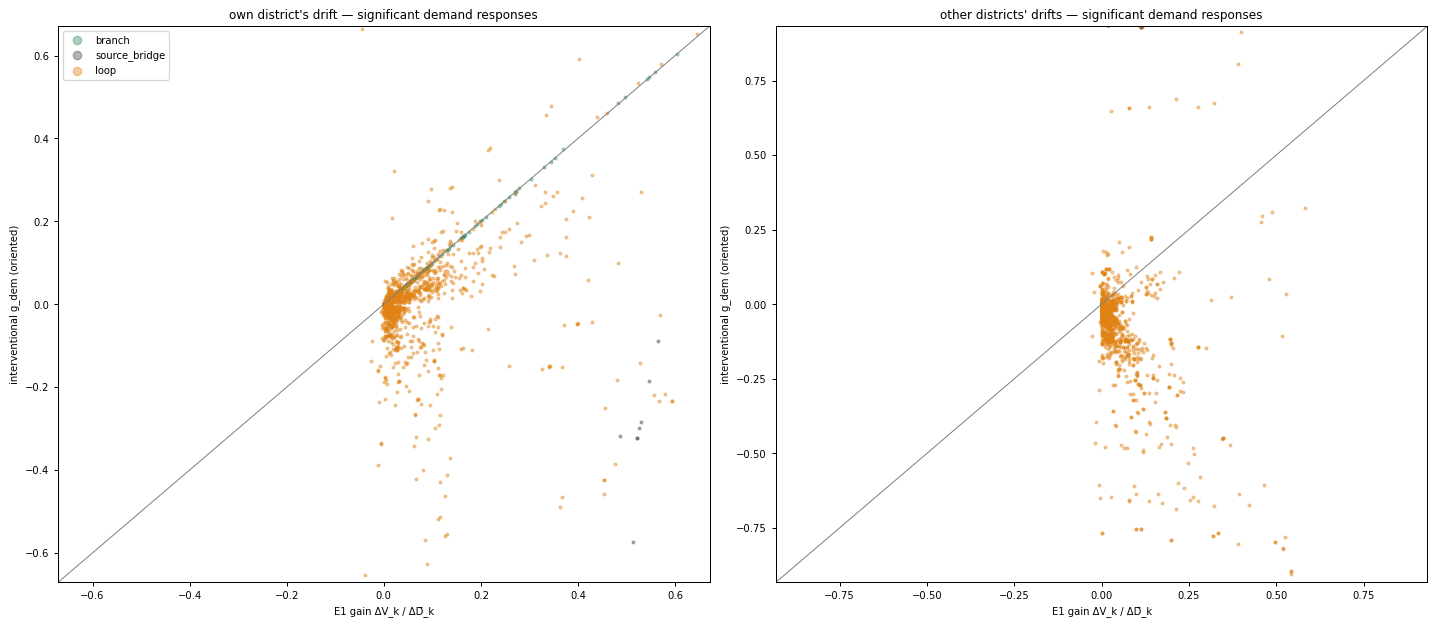

In [7]:
assert_ok()
from scipy.stats import mannwhitneyu


def auc(pos, neg):
    pos, neg = np.asarray(pos, float), np.asarray(neg, float)
    pos, neg = pos[np.isfinite(pos)], neg[np.isfinite(neg)]
    return mannwhitneyu(pos, neg, alternative="two-sided").statistic / (len(pos) * len(neg)) if len(pos) and len(neg) else np.nan


DA = BASE / "dependence_analysis"
LBf = pd.read_parquet(BASE / "dependence" / "labels.parquet")
SE = pd.read_parquet(DA / "sensor_evidence.parquet")
VMx = pd.read_parquet(DA / "sensor_demand_mixture.parquet")
id2el = LBf.drop_duplicates(["districting", "id"]).set_index(["districting", "id"])["element"].astype(str)
SE["link"] = [id2el.get((m, i)) for m, i in zip(SE["districting"], SE["id"])]
VMx["link"] = [id2el.get((m, i)) for m, i in zip(VMx["districting"], VMx["id"])]
dists = sorted(c for c in E1.columns if c.startswith("District"))
sto_c = [c for c in E1.columns if c.startswith("storage:")]
E1["storage_share"] = E1[sto_c].sum(axis=1) if sto_c else 0.0
dsum = E1[dists].sum(axis=1)
for d in dists:
    E1[f"m_{d}"] = E1[d] / dsum.where(dsum > 0)
init = E1[E1["window"] == "init"].drop_duplicates(["districting", "link"])          # init window shared in a partition
cls = SE.drop_duplicates(["districting", "link"])[["districting", "link", "id", "home", "topo", "storage"]]
J = init.merge(cls, on=["districting", "link"])
J = J[J["volume"] > 0]

# (a) storage share
nat = SE.assign(sh=SE["g_sto"].abs() / (SE["g_sto"].abs() + SE["g_dem"].abs())).groupby(["districting", "link"])["sh"].median()
J["native_storage_share_of_response"] = [nat.get((m, l), np.nan) for m, l in zip(J["districting"], J["link"])]
ra = []
for m, g in J.groupby("districting"):
    ra.append({"districting": m, "AUC storage share -> v2 storage class": auc(g[g["storage"]]["storage_share"], g[~g["storage"]]["storage_share"]),
               "Spearman storage share vs native storage share of response": g[["storage_share", "native_storage_share_of_response"]].corr("spearman").iat[0, 1],
               "median storage share: storage-class": g[g["storage"]]["storage_share"].median(),
               "median storage share: demand-class": g[~g["storage"]]["storage_share"].median(),
               "branch links with storage share > 0": int((g[g["topo"] == "branch"]["storage_share"] > 1e-9).sum())})
display(Markdown("**(a) storage share of each link's water vs the storage labels**"))
display(pd.DataFrame(ra).round(3))

# (b) mixtures
vm = VMx.pivot_table(index=["districting", "link"], columns="k", values="v_dem_k", dropna=False)
wl = LBf.assign(link=LBf["element"].astype(str)).drop_duplicates(["districting", "link"]).set_index(["districting", "link"])
rows = []
for r_ in J.itertuples():
    key = (r_.districting, r_.link)
    mvec = np.array([getattr(r_, f"m_{d}") for d in dists], float)
    if not np.isfinite(mvec).all():
        continue
    v = vm.loc[key].reindex(dists).to_numpy(float) if key in vm.index else np.full(len(dists), np.nan)
    wv = wl.loc[key, [f"w_{d}" for d in dists]].to_numpy(float) if key in wl.index else np.full(len(dists), np.nan)
    rows.append({"districting": r_.districting, "link": r_.link, "id": r_.id, "home": r_.home, "topo": r_.topo,
                 "class": "storage" if r_.storage else "demand", "storage_share": r_.storage_share,
                 "L1_v": 0.5 * np.abs(v - mvec).sum() if np.isfinite(v).all() else np.nan,
                 "v_defined": bool(np.isfinite(v).all()),
                 "L1_w": 0.5 * np.abs(wv - mvec).sum() if np.isfinite(wv).all() else np.nan,
                 "dominant_m": dists[int(np.argmax(mvec))],
                 "dominant_v": dists[int(np.nanargmax(v))] if np.isfinite(v).any() else None,
                 "m_home": mvec[dists.index(r_.home)] if r_.home in dists else np.nan})
CMP = pd.DataFrame(rows)
CMP.to_parquet(OUT / "e1_vs_labels.parquet", index=False)
display(Markdown("**(b) $\\tfrac12\\lVert v-m\\rVert_1$ and $\\tfrac12\\lVert w-m\\rVert_1$** (median, q90) and how often $v$ is defined"))
display(CMP.groupby(["districting", "topo", "class"]).agg(
    links=("link", "size"), v_defined=("v_defined", "mean"),
    L1_v_med=("L1_v", "median"), L1_v_q90=("L1_v", lambda x: x.quantile(0.9)),
    L1_w_med=("L1_w", "median"), L1_w_q90=("L1_w", lambda x: x.quantile(0.9))).round(3))
CMPd = CMP.dropna(subset=["dominant_v"])
display(Markdown("dominant district: $v$ vs E1 (links with $v$ defined)"))
display(CMPd.assign(agree=CMPd["dominant_v"] == CMPd["dominant_m"]).groupby(["districting", "class"])["agree"].mean().round(3))
display(Markdown("how pure is each link's water by E1? (share of its own home district's demand)"))
display(CMP.groupby(["districting", "class"])["m_home"].describe(percentiles=[0.1, 0.5, 0.9])[["10%", "50%", "90%"]].round(3))

LONG = []
for r_ in J.itertuples():
    key = (r_.districting, r_.link)
    for d in dists:
        LONG.append({"districting": r_.districting, "link": r_.link, "topo": r_.topo, "storage": r_.storage, "k": d,
                     "m": getattr(r_, f"m_{d}"),
                     "v": vm.at[key, d] if (key in vm.index and d in vm.columns) else np.nan,
                     "w": wl.at[key, f"w_{d}"] if key in wl.index else np.nan})
LONG = pd.DataFrame(LONG)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col in zip(axes, ("v", "w")):
    for tp_, cc in (("branch", "#2e8b57"), ("source_bridge", "#444444"), ("loop", "#e08214")):
        z_ = LONG[LONG["topo"] == tp_]
        ax.scatter(z_["m"], z_[col], s=4, alpha=0.35, color=cc, label=tp_)
    ax.plot([0, 1], [0, 1], color="0.5", lw=0.8)
    ax.set(xlabel="E1 share m (exact, init window)", ylabel=f"{col} (label)", title=f"{col} vs exact mixture — every link × district")
axes[0].legend(markerscale=3)
fig.tight_layout(); plt.show()

# (c) carrying k's water vs responding to k's drift
e = SE[SE["home"] != SE["drift"]].merge(LONG.rename(columns={"k": "drift"})[["districting", "link", "drift", "m"]],
                                        on=["districting", "link", "drift"])
rc = []
for m, g in e.groupby("districting"):
    for lab in ("sig_dem", "sig_sto", "sig_tot", "sig_shape"):
        rc.append({"districting": m, "responds via": lab[4:], "AUC of m_{s,k}": auc(g[g[lab]]["m"], g[~g[lab]]["m"]),
                   "P(responds | m >= 0.05)": float(g[g["m"] >= 0.05][lab].mean()),
                   "P(responds | m < 0.01)": float(g[g["m"] < 0.01][lab].mean())})
display(Markdown("**(c) does carrying $k$'s water (E1) predict a significant response to $k$'s drift?** (off-diagonal)"))
display(pd.DataFrame(rc).pivot_table(index="districting", columns="responds via").round(3))

# (d) E1's own gain vs the interventional demand gain
Dw = E6[E6["window"] != "other"].groupby(["world", "district", "window"])["demand"].mean().unstack("window")
E1w = E1.set_index(["world", "link", "window"])
GD = []
for r_ in SE.dropna(subset=["link"]).itertuples():
    k = r_.drift
    try:
        mi, mf = E1w.loc[(r_.world, r_.link, "init")], E1w.loc[(r_.world, r_.link, "settled")]
        dD = Dw.loc[(r_.world, k), "settled"] - Dw.loc[(r_.world, k), "init"]
    except KeyError:
        continue
    if abs(dD) < 1e-9:
        continue
    Vi, Vf = mi[k] * mi["mean_abs_flow"], mf[k] * mf["mean_abs_flow"]
    GD.append({"districting": r_.districting, "world": r_.world, "drift": k, "link": r_.link, "topo": r_.topo,
               "storage": r_.storage, "own": r_.home == k, "g_e1": (Vf - Vi) / dD, "g_dem": r_.g_dem, "g_tot": r_.g_tot,
               "sig_dem": r_.sig_dem, "m_init": mi[k]})
GD = pd.DataFrame(GD)
GD.to_parquet(OUT / "e1_gain_vs_interventional.parquet", index=False)
rd = []
for (m, tp_, own), g in GD.groupby(["districting", "topo", "own"]):
    gg = g[g["sig_dem"]]
    rd.append({"districting": m, "topo": tp_, "own": own, "n (sig_dem)": len(gg),
               "Spearman g_e1 vs g_dem": gg[["g_e1", "g_dem"]].corr("spearman").iat[0, 1] if len(gg) > 3 else np.nan,
               "median g_dem / g_e1": float((gg["g_dem"] / gg["g_e1"]).replace([np.inf, -np.inf], np.nan).median()) if len(gg) else np.nan,
               "sign agree": float((np.sign(gg["g_dem"]) == np.sign(gg["g_e1"])).mean()) if len(gg) else np.nan})
display(Markdown("**(d) interventional demand gain vs E1's gain** (link-worlds with a significant demand response)"))
display(pd.DataFrame(rd).round(3))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, own in zip(axes, (True, False)):
    z_ = GD[(GD["own"] == own) & GD["sig_dem"]]
    for tp_, cc in (("branch", "#2e8b57"), ("source_bridge", "#444444"), ("loop", "#e08214")):
        q_ = z_[z_["topo"] == tp_]
        ax.scatter(q_["g_e1"], q_["g_dem"], s=5, alpha=0.4, color=cc, label=tp_)
    lim = np.nanpercentile(np.abs(z_[["g_e1", "g_dem"]].to_numpy(float)), 99) if len(z_) else 1
    ax.plot([-lim, lim], [-lim, lim], color="0.5", lw=0.8)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel="E1 gain ΔV_k / ΔD̄_k", ylabel="interventional g_dem (oriented)",
           title=("own district's drift" if own else "other districts' drifts") + " — significant demand responses")
axes[0].legend(markerscale=3)
fig.tight_layout(); plt.show()

 Files

| file | one row per |
|---|---|
| `e6_district_hourly` | world × district × hour (demand, in/out by partner kind, residual, per-partner exchange) |
| `e6_tank_hourly` | world × tank × hour (net inflow, level, volume change from level and from flow) |
| `e6_exchange_window` | partition × drift world × district × window (mean exchange per partner) |
| `e1_link_window` | world × link × window (share per destination, volume, mean flow) |
| `e1_link_hour_of_week` | world × link × window × destination (168 hour-of-week shares) |
| `e1_vs_labels`, `e1_gain_vs_interventional` | partition × link / world × link (the comparisons above) |

In [8]:
display(pd.DataFrame([{"file": f.name, "rows": len(pd.read_parquet(f)), "MB": round(f.stat().st_size / 1e6, 2)}
                      for f in sorted(OUT.glob("*.parquet"))]))

,file,rows,MB
0,e1_branch_check.parquet,1980,0.04
1,e1_gain_vs_interventional.parquet,7236,0.26
2,e1_link_hour_of_week.parquet,130464,33.68
3,e1_link_window.parquet,14496,0.67
4,e1_vs_labels.parquet,1806,0.06
5,e6_district_hourly.parquet,1636992,95.49
6,e6_exchange_window.parquet,96,0.01
7,e6_tank_hourly.parquet,1227744,17.85
